In [156]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

prop = pd.read_csv('./Resources/Data/property_info.csv')
rev = pd.read_csv('./Resources/Data/revenue_per_month.csv')
ss_data = pd.read_csv('Resources/Data/san_berandino_prices.csv')

In [157]:
prop.head()

,Unnamed: 0,unified_id,zipcode,street_name,city,bedrooms,bathrooms,guests,hot_tub,pool
0,0,AIR10052559,92315,Heavenly Valley Road,Big Bear Lake,3,3,8,True,False
1,1,AIR10178668,92315,Round Drive,Big Bear Lake,3,3,7,False,False
2,2,AIR10211700,92315,NaN,Big Bear Lake,5,2,12,False,False
3,3,AIR10344705,92314,NaN,Big Bear City,3,1,5,False,False
4,4,AIR10424683,92315,Starvation Flats Road,Big Bear Lake,3,2,8,False,True


In [158]:
prop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   2126 non-null   int64 
 1   unified_id   2126 non-null   object
 2   zipcode      2126 non-null   int64 
 3   street_name  450 non-null    object
 4   city         2126 non-null   object
 5   bedrooms     2126 non-null   int64 
 6   bathrooms    2126 non-null   int64 
 7   guests       2126 non-null   int64 
 8   hot_tub      2126 non-null   bool  
 9   pool         2126 non-null   bool  
dtypes: bool(2), int64(5), object(3)
memory usage: 137.2+ KB


In [159]:
len(prop['street_name'].unique())

241

In [160]:
rev.head()

,unified_id,year,month,revenue
0,AIR10000347,2023,8,2700.0
1,AIR10000347,2023,7,13950.0
2,AIR10000347,2023,6,13500.0
3,AIR10000347,2023,5,13950.0
4,AIR10000347,2023,4,13500.0


In [161]:
ss_data.head()

,ID,Price,Rent Estimate,Bathrooms,Bedrooms,Living Area,Street Name,City,Zip,Pool
0,JTuph425993,18000000,2435.0,4,3,5470,Uphill Rd,Joshua Tree,92252,False
1,JTave861546,399990,1786.0,2,3,1056,Avenida La Espana Daga,Joshua Tree,92252,False
2,JTpre541921,575000,2300.0,2,3,1577,Prescott Trl,Joshua Tree,92252,False
3,JTana655688,899000,4798.0,2,3,1434,Anaconda Dr,Joshua Tree,92252,False
4,JTpet308672,369900,1825.0,1,3,1040,Petunia Dr,Joshua Tree,92252,False


In [162]:
ss_data['Zip'].unique()

array([92252, 92284, 92314, 92315])

In [163]:
prop['zipcode'].unique()

array([92315, 92314, 92284, 92252])

In [164]:
mean_rev = rev.groupby('unified_id')['revenue'].mean().reset_index()


In [165]:
rev_period = rev.groupby('unified_id')['revenue'].count().reset_index()

In [166]:
odd_rev = rev[rev['revenue']<0]

In [167]:
odd_rev.head()

,unified_id,year,month,revenue
25988,AIR21149220,2020,9,-168.0
28951,AIR21800940,2020,11,-658.0
34312,AIR23265461,2020,6,-649.0
34338,AIR23265783,2020,6,-333.0
34387,AIR23268084,2020,7,-227.0


In [168]:
odd_rev.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, 25988 to 145040
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unified_id  48 non-null     object 
 1   year        48 non-null     int64  
 2   month       48 non-null     int64  
 3   revenue     48 non-null     float64
dtypes: float64(1), int64(2), object(1)
memory usage: 1.9+ KB


In [169]:
rev.count()

unified_id    146547
year          146547
month         146547
revenue       146525
dtype: int64

In [170]:
rev_period.head()

,unified_id,revenue
0,AIR10000347,42
1,AIR10035983,4
2,AIR10052559,47
3,AIR10178668,40
4,AIR10204420,27


In [171]:
df = pd.merge(prop, mean_rev, on='unified_id')

In [172]:
prop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   2126 non-null   int64 
 1   unified_id   2126 non-null   object
 2   zipcode      2126 non-null   int64 
 3   street_name  450 non-null    object
 4   city         2126 non-null   object
 5   bedrooms     2126 non-null   int64 
 6   bathrooms    2126 non-null   int64 
 7   guests       2126 non-null   int64 
 8   hot_tub      2126 non-null   bool  
 9   pool         2126 non-null   bool  
dtypes: bool(2), int64(5), object(3)
memory usage: 137.2+ KB


In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   2126 non-null   int64  
 1   unified_id   2126 non-null   object 
 2   zipcode      2126 non-null   int64  
 3   street_name  450 non-null    object 
 4   city         2126 non-null   object 
 5   bedrooms     2126 non-null   int64  
 6   bathrooms    2126 non-null   int64  
 7   guests       2126 non-null   int64  
 8   hot_tub      2126 non-null   bool   
 9   pool         2126 non-null   bool   
 10  revenue      2126 non-null   float64
dtypes: bool(2), float64(1), int64(5), object(3)
memory usage: 153.8+ KB


<Axes: xlabel='city', ylabel='revenue'>

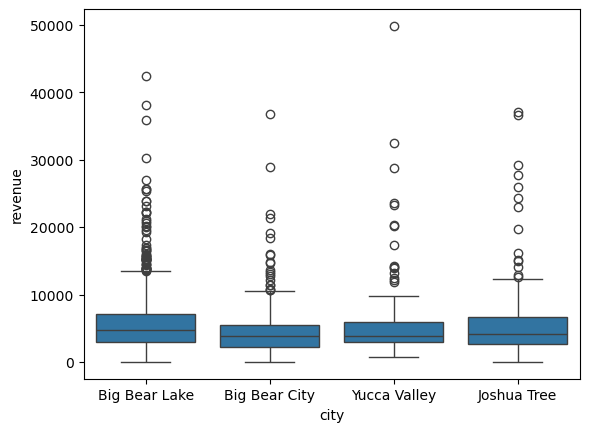

In [174]:
sns.boxplot(data=df, x='city', y='revenue')

<Axes: xlabel='city', ylabel='revenue'>

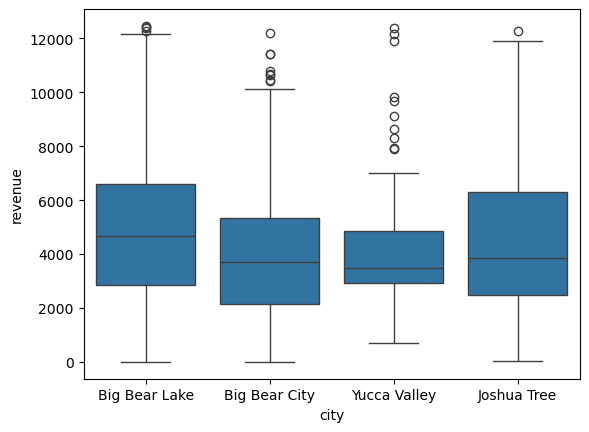

In [175]:
sns.boxplot(data=df[df['revenue'] < 12500], x='city', y='revenue')

In [176]:
df[df['revenue'] < 12500]['revenue'].groupby(df['city']).describe()

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Big Bear City,440.0,3973.008576,2342.928115,0.000000,2135.260417,3692.972564,5346.666667,12211.583333
Big Bear Lake,1263.0,4957.003773,2734.796618,0.000000,2846.829787,4664.659574,6616.981583,12465.717391
Joshua Tree,209.0,4556.183433,2721.138353,42.809524,2499.931034,3842.714286,6309.058824,12281.621622
Yucca Valley,102.0,4236.410583,2324.529604,695.000000,2924.812192,3488.731944,4846.504804,12389.466667


In [177]:
ss_data = ss_data[~ss_data.duplicated(['Living Area','Street Name','City','Zip'],keep=False)]
ss_data = ss_data.dropna()
ss_data = ss_data[ss_data['City'] != 'Panorama Heights']
ss_data = ss_data[ss_data['Price'] < 1800000]
ss_data['Rent Estimate'].groupby(ss_data['City']).describe()

,count,mean,std,min,25%,50%,75%,max
City,,,,,,,,
Big Bear City,46.0,3437.239130,783.069408,2028.0,2996.75,3252.0,4049.25,5114.0
Big Bear Lake,91.0,3622.065934,1452.681060,1952.0,2594.00,2999.0,4530.50,8710.0
Joshua Tree,54.0,2615.574074,1011.460342,1649.0,1853.75,2314.5,2984.00,6627.0
Yucca Valley,93.0,2893.838710,838.757599,1728.0,2298.00,2703.0,3234.00,5000.0


<Axes: xlabel='revenue', ylabel='Count'>

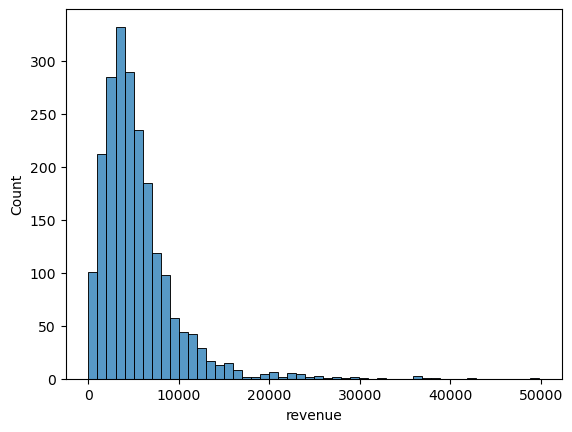

In [178]:
sns.histplot(data=df, x='revenue', bins=50)

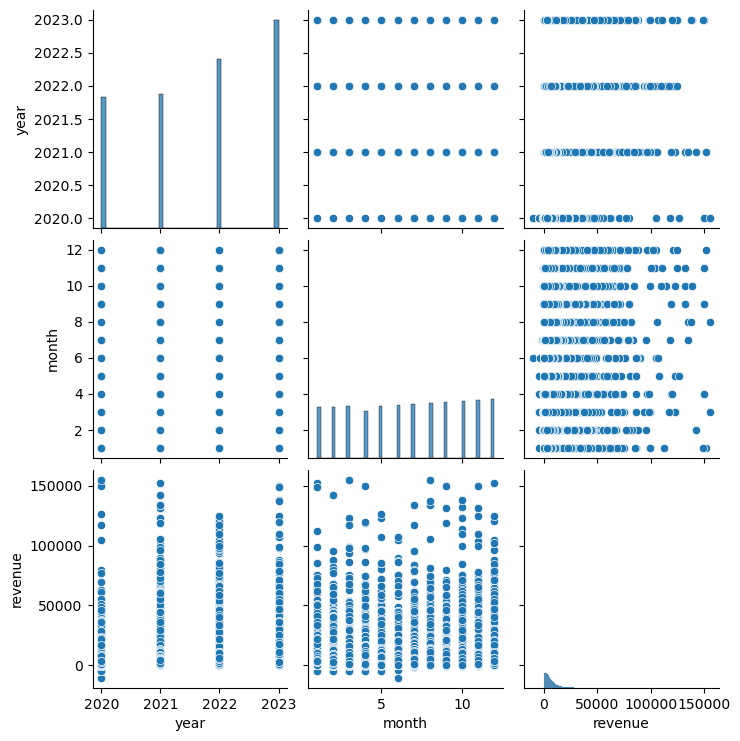

In [179]:
sns.pairplot(rev)

<Axes: xlabel='revenue'>

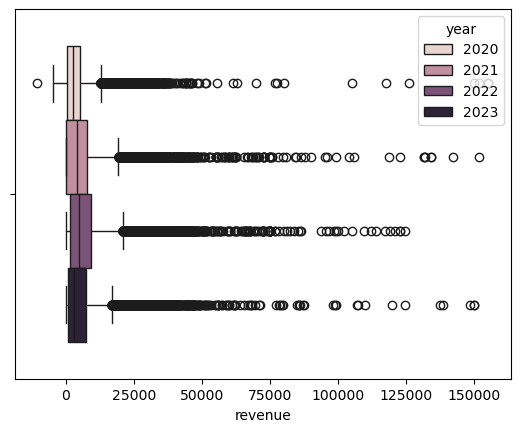

In [180]:
sns.boxplot(rev, x='revenue', hue='year')

In [181]:
merged_rev = rev.groupby('unified_id').agg({'revenue':'mean'})


In [182]:
merged_rev.head()

,revenue
unified_id,
AIR10000347,6942.595238
AIR10035983,6833.750000
AIR10052559,9530.702128
AIR10178668,9687.150000
AIR10204420,7306.925926


In [183]:
rev.info()
print("-----")
prop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146547 entries, 0 to 146546
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   unified_id  146547 non-null  object 
 1   year        146547 non-null  int64  
 2   month       146547 non-null  int64  
 3   revenue     146525 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 4.5+ MB
-----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   2126 non-null   int64 
 1   unified_id   2126 non-null   object
 2   zipcode      2126 non-null   int64 
 3   street_name  450 non-null    object
 4   city         2126 non-null   object
 5   bedrooms     2126 non-null   int64 
 6   bathrooms    2126 non-null   int64 
 7   guests       2126 non-null   int64 
 8   hot_tub      2126 non-null   bool  
 9   pool   

In [184]:
#df = pd.merge(prop, rev, on='unified_id', how='right')

In [185]:
df.head()

,Unnamed: 0,unified_id,zipcode,street_name,city,bedrooms,bathrooms,guests,hot_tub,pool,revenue
0,0,AIR10052559,92315,Heavenly Valley Road,Big Bear Lake,3,3,8,True,False,9530.702128
1,1,AIR10178668,92315,Round Drive,Big Bear Lake,3,3,7,False,False,9687.150000
2,2,AIR10211700,92315,NaN,Big Bear Lake,5,2,12,False,False,9257.500000
3,3,AIR10344705,92314,NaN,Big Bear City,3,1,5,False,False,1148.291667
4,4,AIR10424683,92315,Starvation Flats Road,Big Bear Lake,3,2,8,False,True,1521.791667


In [186]:
df['revenue'].groupby(df['unified_id']).describe()['mean']

unified_id
AIR10000347    6942.595238
AIR10052559    9530.702128
AIR10178668    9687.150000
AIR10204420    7306.925926
AIR10211502    6690.459459
                  ...     
AIR9959855     7088.936170
AIR9960008     6824.130435
AIR9976790     8438.148936
AIR9986505     8157.857143
AIR9996370     2183.979167
Name: mean, Length: 2126, dtype: float64

In [187]:
df.head()

,Unnamed: 0,unified_id,zipcode,street_name,city,bedrooms,bathrooms,guests,hot_tub,pool,revenue
0,0,AIR10052559,92315,Heavenly Valley Road,Big Bear Lake,3,3,8,True,False,9530.702128
1,1,AIR10178668,92315,Round Drive,Big Bear Lake,3,3,7,False,False,9687.150000
2,2,AIR10211700,92315,NaN,Big Bear Lake,5,2,12,False,False,9257.500000
3,3,AIR10344705,92314,NaN,Big Bear City,3,1,5,False,False,1148.291667
4,4,AIR10424683,92315,Starvation Flats Road,Big Bear Lake,3,2,8,False,True,1521.791667


In [188]:
ss_data.head()

,ID,Price,Rent Estimate,Bathrooms,Bedrooms,Living Area,Street Name,City,Zip,Pool
1,JTave861546,399990,1786.0,2,3,1056,Avenida La Espana Daga,Joshua Tree,92252,False
2,JTpre541921,575000,2300.0,2,3,1577,Prescott Trl,Joshua Tree,92252,False
3,JTana655688,899000,4798.0,2,3,1434,Anaconda Dr,Joshua Tree,92252,False
4,JTpet308672,369900,1825.0,1,3,1040,Petunia Dr,Joshua Tree,92252,False
5,JTdem785454,520000,2300.0,2,4,1527,Demesne Rd,Joshua Tree,92252,False


In [189]:
del df[df.columns[0]]

In [190]:
df = df.dropna()
df['bedrooms'] = df['bedrooms'].astype(int)
df['bathrooms'] = df['bathrooms'].astype(int)

In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 450 entries, 0 to 2125
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unified_id   450 non-null    object 
 1   zipcode      450 non-null    int64  
 2   street_name  450 non-null    object 
 3   city         450 non-null    object 
 4   bedrooms     450 non-null    int64  
 5   bathrooms    450 non-null    int64  
 6   guests       450 non-null    int64  
 7   hot_tub      450 non-null    bool   
 8   pool         450 non-null    bool   
 9   revenue      450 non-null    float64
dtypes: bool(2), float64(1), int64(4), object(3)
memory usage: 32.5+ KB


In [192]:
ss_data['Street Name'].unique()

array(['Avenida La Espana Daga', 'Prescott Trl', 'Anaconda Dr',
       'Petunia Dr', 'Demesne Rd', 'Adobe Dr', 'Sunny Sands Dr',
       'Broadway St', 'Navajo Trl', 'Conejo Ave', 'Avenida La Manana',
       'Polaris Ave', 'Alta Mura Dr', 'St S', 'Natoma Trl',
       'Alta Loma Dr', 'Elwood St', 'Granada Dr', 'Rice Ave',
       'El Reposo Cir', 'Morningside Rd', 'Olympic Rd', 'Wesley Rd',
       'Avenida La Mirada Trl', 'Pueblo Trl', 'Grand View Cir',
       'Torres Ave', 'Alta Vista Dr', 'Alta Mesa Dr', 'Hill View Rd',
       'Valley View Dr', 'Campanula St', 'Avenida Del Sol', 'Dennis Ave',
       'Calle Del Rio', 'Oleander Dr', 'Wren Rd', 'El Cajon Dr',
       'Sandalwood Trl', 'Sunset Rd', 'Overhill Rd', 'Center Ave',
       'Venus St', 'Orion Dr', 'Chollita Rd', 'Bonair Rd', 'Sherwood Rd',
       'Desert Gold Dr', 'Breezy Ln', 'Avalon Ave', 'Ventura Ave',
       'Dumosa Ave', 'Primavera Dr', 'Emerson Ave', 'Buena Vista Dr',
       'Meredith Ct', 'San Andreas Rd', 'Saint Marys Dr', 

In [193]:
r_df = set(df['street_name'].unique())

In [194]:
r_ss = set(ss_data['Street Name'].unique())

In [195]:
r_df

{'2nd Lane',
 '3rd Street',
 'Alameda Road',
 'Alpenweg Drive',
 'Alpine Way',
 'Alta Avenue',
 'Alta Loma Drive',
 'Alta Vista Avenue',
 'Angels Camp Road',
 'Antelope Mountain Drive',
 'Aspen Drive',
 'Aster Avenue',
 'Avalon Road',
 'Avenue Tortuga',
 'Balsam Drive',
 'Barrett Way',
 'Base Line Road',
 'Big Bear Boulevard',
 'Blue Jay Road',
 'Bluebird Court',
 'Boulder View Drive',
 'Bow Canyon Road',
 'Brownie Lane',
 'Buffalo Court',
 'Butte Avenue',
 'Calle Del Rio',
 'Cameron Drive',
 'Canvasback Road',
 'Capilla Drive',
 'Cardinal Drive',
 'Carmelita Way',
 'Castlewood Road',
 'Catalina Road',
 'Cedar Avenue',
 'Cedar Mountain Road',
 'Cherry Lane',
 'Chipmunk Lane',
 'Cholla Avenue',
 'Cienega Road',
 'Cinderella Drive',
 'Clover Drive',
 'Club View Drive',
 'Columbine Drive',
 'Colusa Drive',
 'Colusa Lane',
 'Comstock Lane',
 'Conklin Road',
 'Constellation Drive',
 'Copper Mesa Road',
 'Cougar Road',
 'Cove Drive',
 'Crater Lake Road',
 'Creek Road',
 'Crestwood Drive',
 '

In [196]:
r_ss

{'Adobe Dr',
 'Alpenweg Dr',
 'Alta Loma Dr',
 'Alta Mesa Dr',
 'Alta Mura Dr',
 'Alta Vista Ave',
 'Alta Vista Dr',
 'Amador Ave',
 'Anaconda Dr',
 'Antelope Trl',
 'Arastre Rd',
 'Aster Ave',
 'Avalon Ave',
 'Avalon Rd',
 'Avenida Del Sol',
 'Avenida La Espana Daga',
 'Avenida La Manana',
 'Avenida La Mirada Trl',
 'Aviation Dr',
 'Baldwin Lake Rd',
 'Balsa Ave',
 'Bear Loop',
 'Bear Mountain Rd',
 'Bernhardt Ln',
 'Big Bear Blvd',
 'Black Rock Canyon Rd',
 'Bonair Rd',
 'Bonita Ave',
 'Bonita Ln',
 'Bonita Trl',
 'Bow Canyon Rd',
 'Breezy Ln',
 'Brewer Way',
 'Broadway St',
 'Buena Vista Dr',
 'Buffalo Ct',
 'Butte Ave',
 'Calle Del Rio',
 'Cameron Dr',
 'Campanula St',
 'Campero Dr',
 'Canterbury St',
 'Carlyle Dr',
 'Carmelita Cir',
 'Cascade Rd',
 'Castle Crag Rd',
 'Castlewood Dr',
 'Cedar Ave',
 'Cedar Mountain Rd',
 'Center Ave',
 'Cheechaco Trl',
 'Chincapin Rd',
 'Chipmunk Ln',
 'Chollita Rd',
 'Cienega Rd',
 'Cobalt Rd',
 'Condalia Ave',
 'Conejo Ave',
 'Conklin Rd',
 'Cove

In [197]:
r_ss.intersection(r_df)

{'Calle Del Rio'}

In [198]:
di = {'Rd':'Road', 'St':'Street', 'Ave':'Avenue', 'Blvd':'Boulevard', 'Dr':'Drive', 'Ln':'Lane', 'Ct':'Court', 'Pl':'Place', 'Ter':'Terrace', 'Cir':'Circle'}

In [199]:
ss_data['Street Name'].replace(di, regex=True, inplace=True)

/tmp/ipykernel_29511/2166607037.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ss_data['Street Name'].replace(di, regex=True, inplace=True)


In [200]:
combined = pd.merge(df, ss_data, left_on=['street_name','city','bathrooms','bedrooms'], right_on=['Street Name','City','Bathrooms','Bedrooms'], how='inner')

In [201]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   unified_id     58 non-null     object 
 1   zipcode        58 non-null     int64  
 2   street_name    58 non-null     object 
 3   city           58 non-null     object 
 4   bedrooms       58 non-null     int64  
 5   bathrooms      58 non-null     int64  
 6   guests         58 non-null     int64  
 7   hot_tub        58 non-null     bool   
 8   pool           58 non-null     bool   
 9   revenue        58 non-null     float64
 10  ID             58 non-null     object 
 11  Price          58 non-null     int64  
 12  Rent Estimate  58 non-null     float64
 13  Bathrooms      58 non-null     int64  
 14  Bedrooms       58 non-null     int64  
 15  Living Area    58 non-null     int64  
 16  Street Name    58 non-null     object 
 17  City           58 non-null     object 
 18  Zip         

In [208]:
combined[['Price','Rent Estimate','revenue','city']].head()

,Price,Rent Estimate,revenue,city
0,1029900,4772.0,9530.702128,Big Bear Lake
1,595000,2392.0,2855.659574,Big Bear Lake
2,794900,2463.0,7572.553191,Big Bear Lake
3,625000,3229.0,3411.659574,Big Bear Lake
4,645000,2999.0,5529.125000,Big Bear City


<Axes: xlabel='Rent Estimate', ylabel='revenue'>

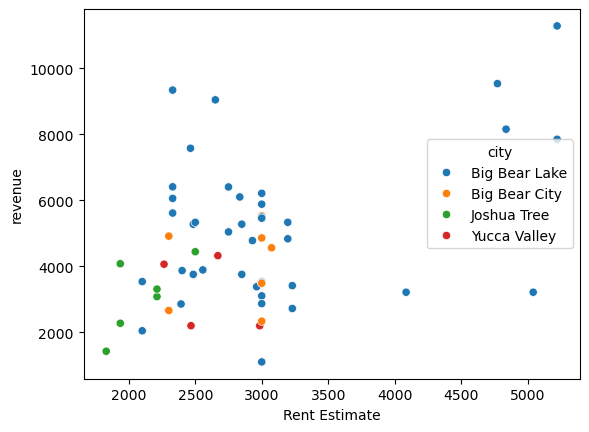

In [209]:
sns.scatterplot(data=combined, x='Rent Estimate', y='revenue', hue='city')

<Axes: ylabel='revenue'>

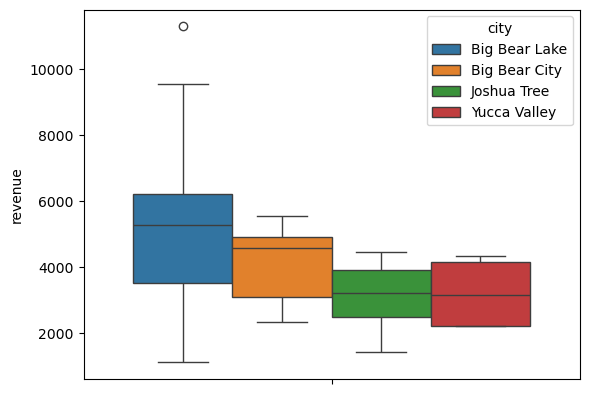

In [210]:
sns.boxplot(data=combined, y='revenue', hue='city')

<Axes: ylabel='Rent Estimate'>

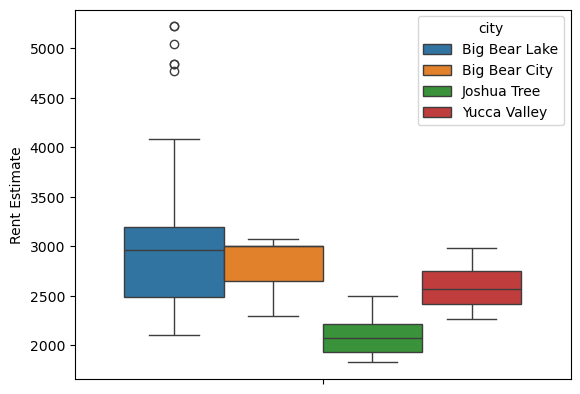

In [211]:
sns.boxplot(data=combined, y='Rent Estimate', hue='city')

In [212]:
sub_df = combined[['Rent Estimate','revenue','city']]

In [219]:
r = sub_df[['Rent Estimate','city']]

In [222]:
r['type'] = 'Rent Estimate'
r.rename(columns={'Rent Estimate':'value'}, inplace=True)

In [223]:
r.head()

,value,city,type
0,4772.0,Big Bear Lake,Rent Estimate
1,2392.0,Big Bear Lake,Rent Estimate
2,2463.0,Big Bear Lake,Rent Estimate
3,3229.0,Big Bear Lake,Rent Estimate
4,2999.0,Big Bear City,Rent Estimate


In [224]:
l = sub_df[['revenue','city']]
l['type'] = 'Revenue'
l.rename(columns={'revenue':'value'}, inplace=True)

In [225]:
c = pd.concat([l,r], ignore_index=True)

<Axes: xlabel='city', ylabel='value'>

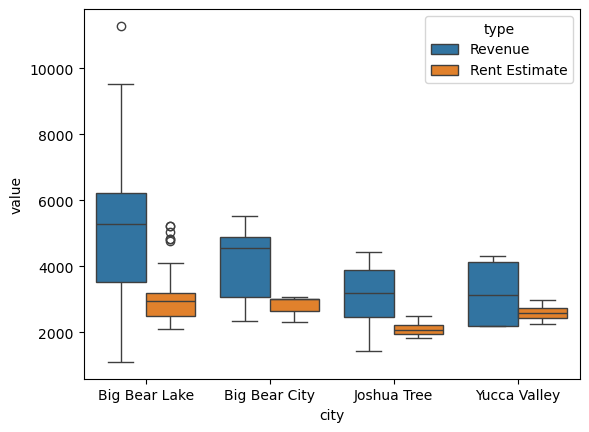

In [227]:
sns.boxplot(data=c, x='city', y='value', hue='type')

In [228]:
df.head()

,unified_id,zipcode,street_name,city,bedrooms,bathrooms,guests,hot_tub,pool,revenue
0,AIR10052559,92315,Heavenly Valley Road,Big Bear Lake,3,3,8,True,False,9530.702128
1,AIR10178668,92315,Round Drive,Big Bear Lake,3,3,7,False,False,9687.150000
4,AIR10424683,92315,Starvation Flats Road,Big Bear Lake,3,2,8,False,True,1521.791667
5,AIR10471190,92314,Spruce Lane,Big Bear City,3,2,8,True,False,4678.702128
6,AIR10551482,92314,La Crescenta Drive,Big Bear City,5,4,15,True,False,8907.479167


In [229]:
Y = df['revenue']
X = df[['city', 'bathrooms', 'bedrooms']]
X = pd.get_dummies(data=X, drop_first=True)
X.head()

,bathrooms,bedrooms,city_Big Bear Lake,city_Joshua Tree,city_Yucca Valley
0,3,3,True,False,False
1,3,3,True,False,False
4,2,3,True,False,False
5,2,3,False,False,False
6,4,5,False,False,False


In [231]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn import preprocessing


Y = df['revenue']
X = df[['city', 'bathrooms', 'bedrooms']]
X = pd.get_dummies(data=X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=11)

model = LinearRegression()

model.fit(X_train,y_train)

predictions = model.predict(X_test)

r2 = r2_score(y_test, predictions)

# model evaluation
print(
  'mean_squared_error : ', mean_squared_error(y_test, predictions))
print(
  'root mean_squared_error : ', mean_squared_error(y_test, predictions)**0.5)
print(
  'mean_absolute_error : ', mean_absolute_error(y_test, predictions))
print('r2_score : ', r2)

print("Intercept:", model.intercept_)


coeff_df2 = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
print("\nFeature Coefficients:\n", coeff_df2)

mean_squared_error :  9640891.010149114
root mean_squared_error :  3104.9784234595118
mean_absolute_error :  2149.037631254426
r2_score :  0.2848954451424224
Intercept: -4166.546185185915

Feature Coefficients:
               Feature  Coefficient
0           bathrooms  1227.799125
1            bedrooms  1633.430086
2  city_Big Bear Lake   850.310103
3    city_Joshua Tree  1209.695476
4   city_Yucca Valley  2258.240143


In [249]:
print('two bed one bath Big Bear City',2.3*1227.799125 + 3.2*1633.430086 - 4166)

two bed one bath Big Bear City 3884.9142627


In [247]:
df[['bedrooms','bathrooms']].groupby(df['city']).describe()

bedrooms                                              bathrooms  \
                 count      mean       std  min  25%  50%  75%  max     count   
city                                                                            
Big Bear City     82.0  3.256098  0.516660  3.0  3.0  3.0  3.0  5.0      82.0   
Big Bear Lake    326.0  3.487730  0.664370  3.0  3.0  3.0  4.0  5.0     326.0   
Joshua Tree       30.0  3.200000  0.406838  3.0  3.0  3.0  3.0  4.0      30.0   
Yucca Valley      12.0  3.416667  0.668558  3.0  3.0  3.0  4.0  5.0      12.0   

                                                            
                   mean       std  min  25%  50%  75%  max  
city                                                        
Big Bear City  2.378049  0.659971  1.0  2.0  2.0  3.0  4.0  
Big Bear Lake  2.717791  0.877123  1.0  2.0  3.0  3.0  7.0  
Joshua Tree    2.100000  0.480660  1.0  2.0  2.0  2.0  3.0  
Yucca Valley   2.416667  0.900337  1.0  2.0  2.0  3.0  4.0

<Axes: xlabel='city', ylabel='value'>

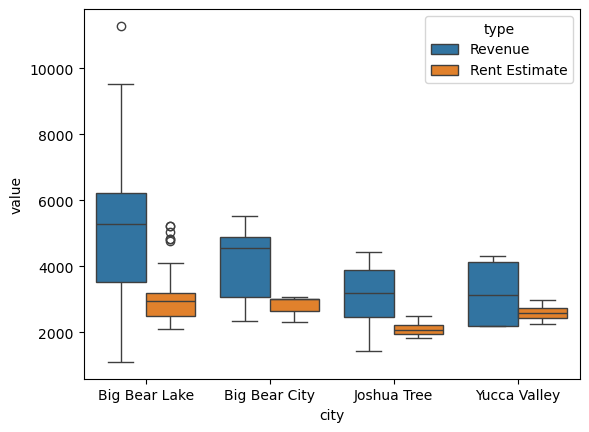

In [244]:
sns.boxplot(data=c, x='city', y='value', hue='type')

<Axes: xlabel='revenue'>

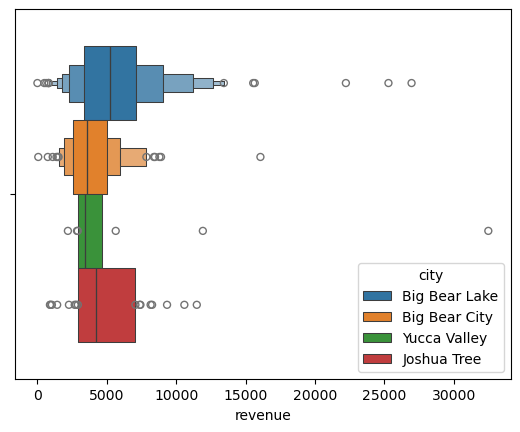

In [203]:
sns.boxenplot(df, x='revenue', hue='city')

<Axes: xlabel='revenue'>

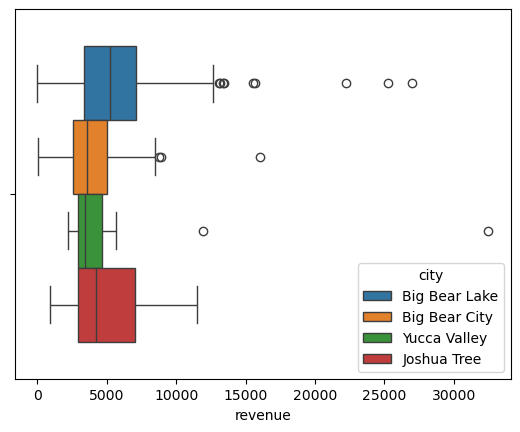

In [204]:
sns.boxplot(df, x='revenue', hue='city')

In [205]:
sns.lineplot(df, x='month', y='revenue', hue='city')

ValueError: Could not interpret value `month` for `x`. An entry with this name does not appear in `data`.

<Axes: xlabel='revenue', ylabel='Count'>

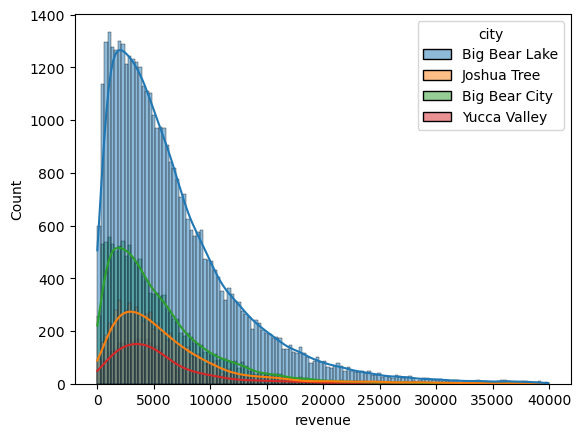

In [ ]:
sns.histplot(df[(df['revenue']<40000) & (df['revenue']>0)], x='revenue', hue='city', kde=True)

<Axes: xlabel='revenue', ylabel='Count'>

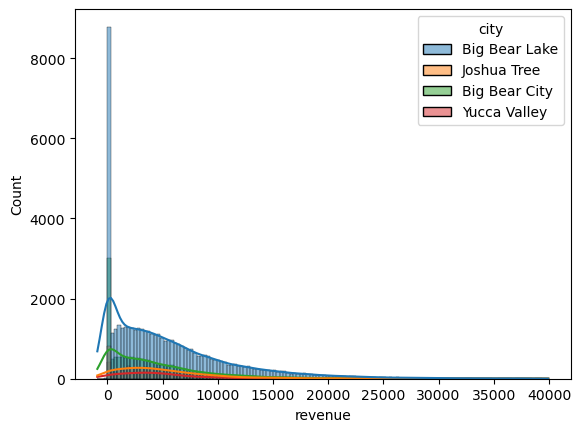

In [ ]:
sns.histplot(df[(df['revenue']<40000)], x='revenue', hue='city', kde=True)

<Axes: xlabel='revenue'>

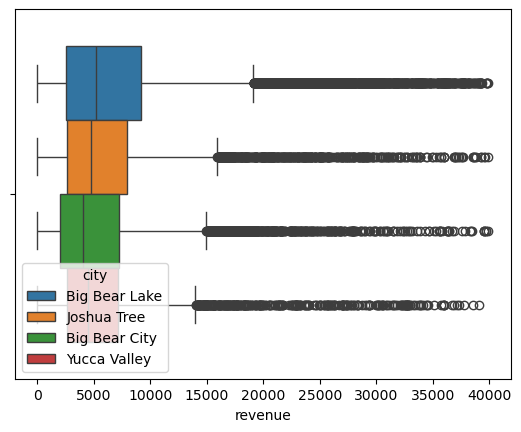

In [ ]:
sns.boxplot(df[(df['revenue']<40000) & (df['revenue']>0)], x='revenue', hue='city')